# 01 — FSDD dataset EDA
Đọc `data/manifest.csv` (tạo bởi `src/build_manifest.py`) và sinh các hình dataset cho báo cáo.

## Cell 1 — Import và load manifest

In [1]:
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / 'src'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import plotstyle; plotstyle.apply()
from plotstyle import SERIES, TEXT2
FIG = ROOT / 'results' / 'figures'; FIG.mkdir(parents=True, exist_ok=True)
df = pd.read_csv(ROOT / 'data' / 'manifest.csv')
display(df.head())
print('shape:', df.shape)
print('speakers:', sorted(df.speaker.unique()))
print('labels:', sorted(int(x) for x in df.label.unique()))

,filename,path,label,speaker,recording_index,sample_rate,num_samples,duration_sec,channels,subtype,sha256,name_ok,readable,error
0,0_george_0.wav,data/fsdd/recordings/0_george_0.wav,0,george,0,8000,2384,0.298000,1,PCM_16,228ab63fccdf262d2e05817b6ec918b15e7d9e4bfb6bb2...,True,True,NaN
1,0_george_1.wav,data/fsdd/recordings/0_george_1.wav,0,george,1,8000,4727,0.590875,1,PCM_16,239d40931baf4e9b482361abb6e021439eca20f2e95f03...,True,True,NaN
2,0_george_10.wav,data/fsdd/recordings/0_george_10.wav,0,george,10,8000,5958,0.744750,1,PCM_16,3fb791b3226b53859b06d7ad2232109ab8bf8ab7b33e6a...,True,True,NaN
3,0_george_11.wav,data/fsdd/recordings/0_george_11.wav,0,george,11,8000,3661,0.457625,1,PCM_16,a9e10d1886318ea4c14eae782fa900ff68e98008391198...,True,True,NaN
4,0_george_12.wav,data/fsdd/recordings/0_george_12.wav,0,george,12,8000,4050,0.506250,1,PCM_16,0b3cf9a042af8bc20f6b35c24f0d178a0e999fcbafa855...,True,True,NaN


shape: (3000, 14)
speakers: ['george', 'jackson', 'lucas', 'nicolas', 'theo', 'yweweler']
labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


## Cell 2 — Thống kê tổng quan

In [2]:
d = df.duration_sec
stats = pd.Series({
    'total samples': len(df), 'number of speakers': df.speaker.nunique(),
    'number of classes': df.label.nunique(), 'sample rate(s)': sorted(df.sample_rate.unique()),
    'channels': sorted(df.channels.unique()),
    'duration min (s)': round(d.min(), 4), 'duration max (s)': round(d.max(), 4),
    'duration mean (s)': round(d.mean(), 4), 'duration std (s)': round(d.std(), 4)})
stats.to_frame('value')

,value
total samples,3000
number of speakers,6
number of classes,10
sample rate(s),[8000]
channels,[1]
duration min (s),0.1435
duration max (s),2.2828
duration mean (s),0.4374
duration std (s),0.1476


## Cell 3 — Số mẫu theo speaker

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


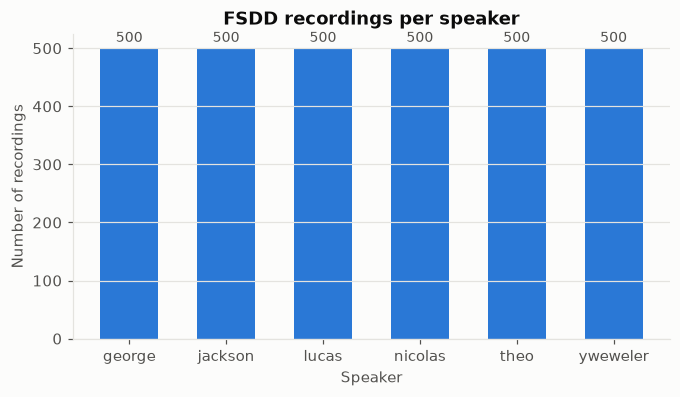

In [3]:
spk_counts = df.speaker.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7, 3.6))
bars = ax.bar(spk_counts.index, spk_counts.values, color=SERIES[0], width=0.6)
ax.bar_label(bars, padding=2, color=TEXT2, fontsize=9)
ax.set(xlabel='Speaker', ylabel='Number of recordings', title='FSDD recordings per speaker')
ax.grid(axis='x', visible=False)
fig.savefig(FIG / 'dataset_samples_per_speaker.png'); plt.show()

## Cell 4 — Số mẫu theo digit

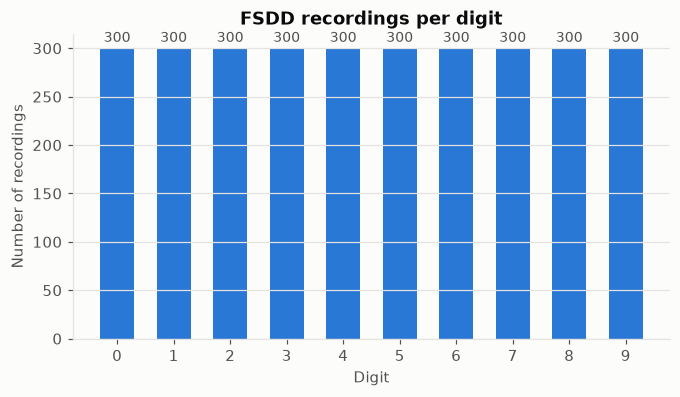

In [4]:
dig_counts = df.label.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7, 3.6))
bars = ax.bar(dig_counts.index.astype(str), dig_counts.values, color=SERIES[0], width=0.6)
ax.bar_label(bars, padding=2, color=TEXT2, fontsize=9)
ax.set(xlabel='Digit', ylabel='Number of recordings', title='FSDD recordings per digit')
ax.grid(axis='x', visible=False)
fig.savefig(FIG / 'dataset_samples_per_digit.png'); plt.show()

## Cell 5 — Ma trận speaker × digit

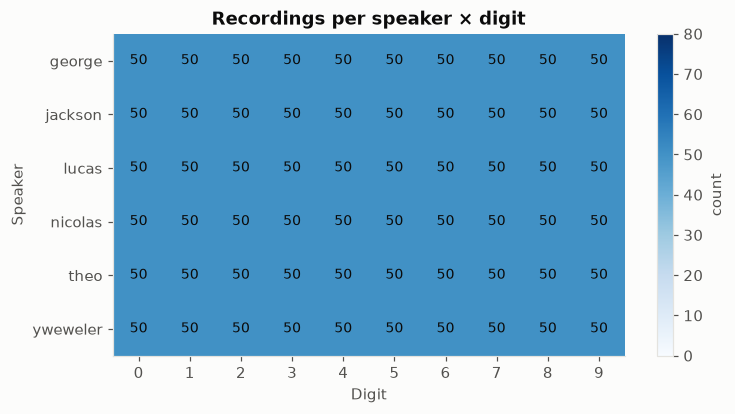

label,0,1,2,3,4,5,6,7,8,9
speaker,,,,,,,,,,
george,50,50,50,50,50,50,50,50,50,50
jackson,50,50,50,50,50,50,50,50,50,50
lucas,50,50,50,50,50,50,50,50,50,50
nicolas,50,50,50,50,50,50,50,50,50,50
theo,50,50,50,50,50,50,50,50,50,50
yweweler,50,50,50,50,50,50,50,50,50,50


In [5]:
ct = pd.crosstab(df.speaker, df.label)
fig, ax = plt.subplots(figsize=(7.5, 3.8))
im = ax.imshow(ct.values, cmap='Blues', vmin=0, vmax=max(ct.values.max(), 1) * 1.6, aspect='auto')
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        ax.text(j, i, ct.values[i, j], ha='center', va='center', fontsize=9)
ax.set_xticks(range(ct.shape[1]), ct.columns); ax.set_yticks(range(ct.shape[0]), ct.index)
ax.set(xlabel='Digit', ylabel='Speaker', title='Recordings per speaker × digit'); ax.grid(False)
fig.colorbar(im, ax=ax, label='count')
fig.savefig(FIG / 'dataset_speaker_digit_matrix.png'); plt.show()
ct

## Cell 6 — Phân bố thời lượng

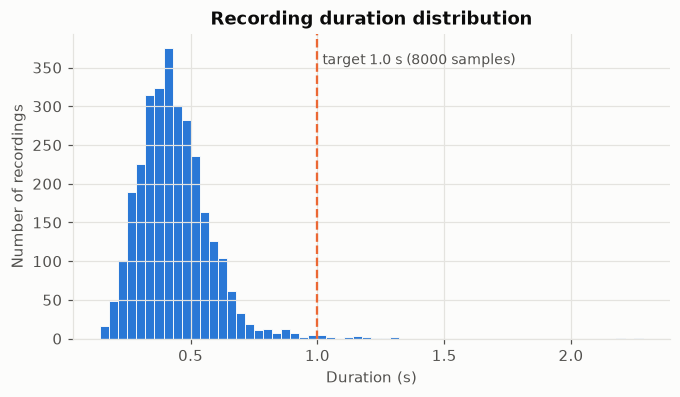

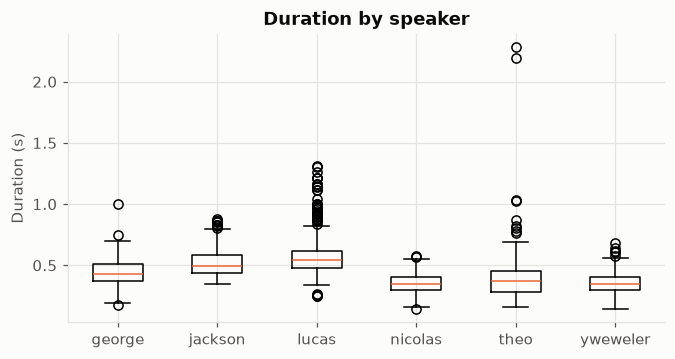

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.hist(d, bins=60, color=SERIES[0], edgecolor='#fcfcfb', linewidth=0.6)
ax.axvline(1.0, color=SERIES[1], linestyle='--', linewidth=1.5)
ax.text(1.02, ax.get_ylim()[1] * 0.9, 'target 1.0 s (8000 samples)', color=TEXT2, fontsize=9)
ax.set(xlabel='Duration (s)', ylabel='Number of recordings', title='Recording duration distribution')
fig.savefig(FIG / 'dataset_duration_distribution.png'); plt.show()
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.boxplot([g.duration_sec for _, g in df.groupby('speaker')], tick_labels=sorted(df.speaker.unique()))
ax.set(ylabel='Duration (s)', title='Duration by speaker'); plt.show()

## Cell 7 — Số file PAD / KEEP / CROP

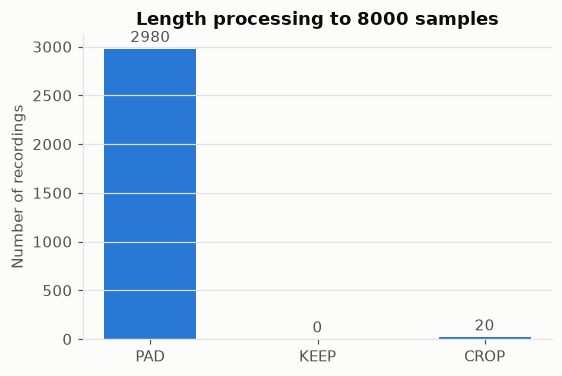

action,PAD,KEEP,CROP
speaker,,,
george,500,0,0
jackson,500,0,0
lucas,484,0,16
nicolas,500,0,0
theo,496,0,4
yweweler,500,0,0


action,PAD,KEEP,CROP
label,,,
0,299,0,1
1,299,0,1
2,299,0,1
3,298,0,2
4,299,0,1
5,298,0,2
6,300,0,0
7,294,0,6
8,298,0,2


In [7]:
from audio import length_action
df['action'] = df.num_samples.map(length_action)
act = df.action.value_counts().reindex(['PAD', 'KEEP', 'CROP'], fill_value=0)
fig, ax = plt.subplots(figsize=(5.5, 3.6))
bars = ax.bar(act.index, act.values, color=SERIES[0], width=0.55)
ax.bar_label(bars, padding=2, color=TEXT2)
ax.set(ylabel='Number of recordings', title='Length processing to 8000 samples'); ax.grid(axis='x', visible=False)
fig.savefig(FIG / 'dataset_length_processing.png'); plt.show()
display(pd.crosstab(df.speaker, df.action).reindex(columns=['PAD','KEEP','CROP'], fill_value=0))
display(pd.crosstab(df.label, df.action).reindex(columns=['PAD','KEEP','CROP'], fill_value=0))

## Cell 8 — Waveform minh họa (3 digit, 3 speaker khác nhau)

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


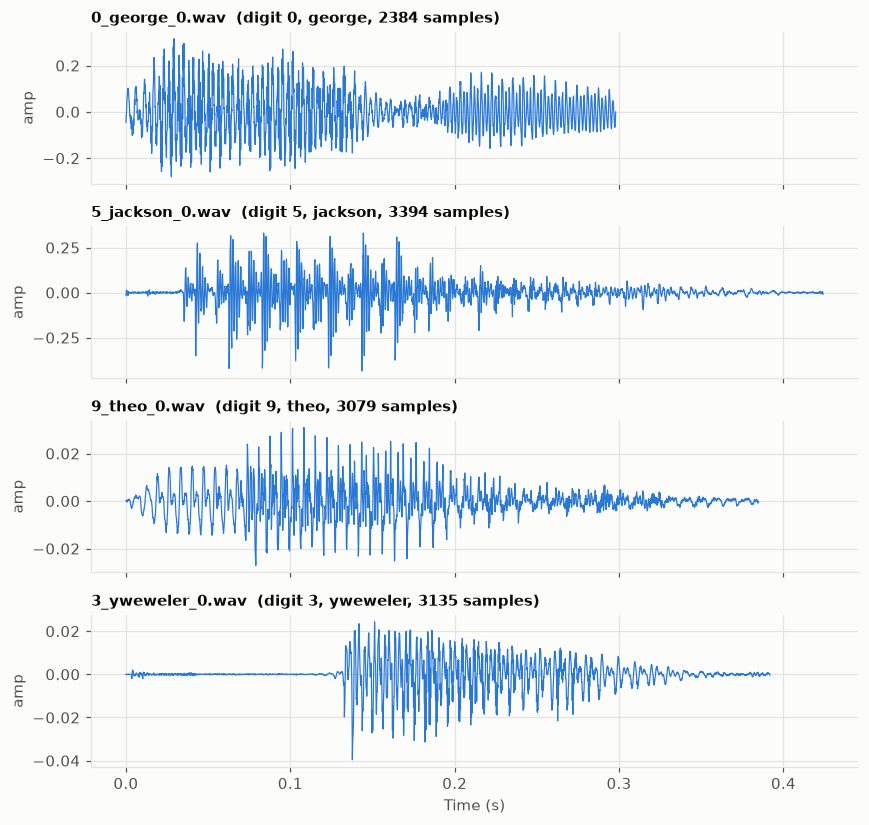

In [8]:
from audio import load_wav
picks = [(0, 'george'), (5, 'jackson'), (9, 'theo'), (3, 'yweweler')]
fig, axes = plt.subplots(len(picks), 1, figsize=(8, 1.9 * len(picks)), sharex=True)
for ax, (dig, spk) in zip(axes, picks):
    row = df[(df.label == dig) & (df.speaker == spk)].sort_values('recording_index').iloc[0]
    y, sr = load_wav(ROOT / row.path)
    ax.plot(np.arange(len(y)) / sr, y, color=SERIES[0], linewidth=0.8)
    ax.set_title(f'{row.filename}  (digit {dig}, {spk}, {len(y)} samples)', fontsize=10, loc='left')
    ax.set_ylabel('amp')
axes[-1].set_xlabel('Time (s)'); fig.tight_layout()
fig.savefig(FIG / 'waveform_examples.png'); plt.show()

## Cell 9 — Summary tự sinh từ dữ liệu

In [9]:
spk_bal = spk_counts.nunique() == 1
dig_bal = dig_counts.nunique() == 1
summary = f'''- Tổng số recordings: {len(df)}
- Số speaker: {df.speaker.nunique()} ({', '.join(sorted(df.speaker.unique()))})
- Số class: {df.label.nunique()}
- Duration trung bình: {d.mean():.3f} s (std {d.std():.3f}, min {d.min():.3f}, max {d.max():.3f})
- Số file cần padding (N < 8000): {act['PAD']}
- Số file giữ nguyên (N = 8000): {act['KEEP']}
- Số file cần crop (N > 8000): {act['CROP']}
- Cân bằng theo speaker: {'CÓ' if spk_bal else 'KHÔNG'} ({spk_counts.min()}–{spk_counts.max()} file/speaker)
- Cân bằng theo digit: {'CÓ' if dig_bal else 'KHÔNG'} ({dig_counts.min()}–{dig_counts.max()} file/digit)
- Mỗi cặp speaker × digit: {ct.values.min()}–{ct.values.max()} file'''
print(summary)
(ROOT / 'results' / 'logs' / 'dataset_eda_summary.txt').write_text(summary + '\n')

- Tổng số recordings: 3000
- Số speaker: 6 (george, jackson, lucas, nicolas, theo, yweweler)
- Số class: 10
- Duration trung bình: 0.437 s (std 0.148, min 0.143, max 2.283)
- Số file cần padding (N < 8000): 2980
- Số file giữ nguyên (N = 8000): 0
- Số file cần crop (N > 8000): 20
- Cân bằng theo speaker: CÓ (500–500 file/speaker)
- Cân bằng theo digit: CÓ (300–300 file/digit)
- Mỗi cặp speaker × digit: 50–50 file


417